In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Project 1: Data Infrastructure

All data acquisition for the MPTE research project:
1. **FRED macro panel** — 34 monthly + 13 quarterly series (Brini & Seregina Appendix D)
2. **S&P 500 daily prices** — WRDS/CRSP for realized volatility
3. **Fama-French factors** — Ken French's data library via pandas_datareader

### Prerequisites
```
pip install fredapi pandas numpy matplotlib pandas_datareader
```

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
import warnings
warnings.filterwarnings('ignore')
from fredapi import Fred

# ============================================================
# SET YOUR FRED API KEY HERE
# Get one free at: https://fred.stlouisfed.org/docs/api/api_key.html
# ============================================================
FRED_API_KEY = 'db0e8230b3719503f33a50ae27dc9f2a'   # <-- Replace this

fred = Fred(api_key=FRED_API_KEY)

DATA_DIR = './data'
os.makedirs(DATA_DIR, exist_ok=True)

print('Setup complete.')


Setup complete.


## 1. Define the 48 variables from the paper (Appendix D)

Each variable has:
- **FRED series ID** (what the API needs)
- **Transformation code** (for stationarity, per FRED-MD/QD conventions)
- **Category** and **description** from the paper

Transformation codes:
1. No transformation
2. First difference
3. Second difference
4. Log
5. Log first difference (growth rate)
6. Log second difference
7. Percent change of first difference

In [6]:
# Monthly variables (Table D.1)
# Format: paper_name -> (fred_series_id, tcode, category, description)

MONTHLY_VARS = {
    'RPI':             ('RPI',             5, 'Output',      'Real Personal Income'),
    'INDPRO':          ('INDPRO',          5, 'Output',      'Industrial Production Index'),
    'CUMFNS':          ('CUMFNS',          2, 'Output',      'Capacity Utilization: Manufacturing'),
    'HWI':             ('JTSJOL',          2, 'Labor',       'Job Openings (replaces discontinued HWI)'),
    'CLF16OV':         ('CLF16OV',         5, 'Labor',       'Civilian Labor Force'),
    'CE16OV':          ('CE16OV',          5, 'Labor',       'Civilian Employment'),
    'UEMPMEAN':        ('UEMPMEAN',        2, 'Labor',       'Average Duration of Unemployment'),
    'CLAIMSx':         ('ICSA',            5, 'Labor',       'Initial Unemployment Claims'),
    'PAYEMS':          ('PAYEMS',          5, 'Labor',       'Total Nonfarm Payroll Employment'),
    'CES0600000007':   ('CES0600000007',   1, 'Labor',       'Avg. Weekly Hours, Goods-Producing'),
    'CES0600000008':   ('CES0600000008',   6, 'Labor',       'Avg. Hourly Earnings, Goods-Producing'),
    'CES2000000008':   ('CES2000000008',   6, 'Labor',       'Avg. Hourly Earnings, Construction'),
    'CES3000000008':   ('CES3000000008',   6, 'Labor',       'Avg. Hourly Earnings, Manufacturing'),
    'AWOTMAN':         ('AWOTMAN',         2, 'Labor',       'Avg. Weekly Overtime Hours, Manufacturing'),
    'AWHMAN':          ('AWHMAN',          1, 'Labor',       'Avg. Weekly Hours, Manufacturing'),
    'HOUST':           ('HOUST',           4, 'Housing',     'Housing Starts'),
    'DPCERA3M086SBEA': ('DPCERA3M086SBEA', 5, 'Consumption', 'Real Personal Consumption Expenditures'),
    'BUSINVx':         ('BUSINV',          5, 'Inventories', 'Total Business Inventories'),
    'RETAILx':         ('RSAFS',           5, 'Consumption', 'Retail and Food Services Sales'),
    'CMRMTSPLx':       ('CMRMTSPL',        5, 'Output',      'Real Manufacturing and Trade Sales'),
    'M2REAL':          ('M2REAL',          5, 'Money',       'Real M2 Money Stock'),
    'TOTRESNS':        ('TOTRESNS',        6, 'Money',       'Total Reserves of Depository Institutions'),
    'BUSLOANS':        ('BUSLOANS',        6, 'Credit',      'Commercial and Industrial Loans'),
    'NONREVSL':        ('NONREVSL',        6, 'Credit',      'Nonrevolving Consumer Credit'),
    'FEDFUNDS':        ('FEDFUNDS',        2, 'Rates',       'Effective Federal Funds Rate'),
    'GS1':             ('GS1',             2, 'Rates',       '1-Year Treasury Yield'),
    'GS10':            ('GS10',            2, 'Rates',       '10-Year Treasury Yield'),
    'BAA':             ('BAA',             2, 'Rates',       "Moody's Baa Corporate Bond Yield"),
    'PCEPI':           ('PCEPI',           6, 'Prices',      'PCE Price Index'),
    'WPSFD49207':      ('WPSFD49207',      6, 'Prices',      'PPI: Finished Goods'),
    'OILPRICEx':       ('WTISPLC',         6, 'Prices',      'Crude Oil Price (WTI)'),
    'S&P 500':         ('SP500',           5, 'Financial',   'S&P 500 Stock Index'),
    'TB3MS':           ('TB3MS',           2, 'Rates',       '3-Month Treasury Bill Rate'),
    'TB6MS':           ('TB6MS',           2, 'Rates',       '6-Month Treasury Bill Rate'),
}

# Quarterly variables (Table D.2)
QUARTERLY_VARS = {
    'GDPC1':    ('GDPC1',    5, 'Output',      'Real Gross Domestic Product'),
    'GPDIC1':   ('GPDIC1',   5, 'Investment',  'Real Gross Private Domestic Investment'),
    'PCECC96':  ('PCECC96',  5, 'Consumption', 'Real Personal Consumption Expenditures'),
    'DPIC96':   ('DPIC96',   5, 'Income',      'Real Disposable Personal Income'),
    'OUTNFB':   ('OUTNFB',   5, 'Output',      'Nonfarm Business Sector Output'),
    'UNRATE':   ('UNRATE',   2, 'Labor',       'Civilian Unemployment Rate'),
    'PCECTPI':  ('PCECTPI',  5, 'Prices',      'PCE Chain-Type Price Index'),
    'PCEPILFE': ('PCEPILFE', 5, 'Prices',      'PCE Price Index Less Food and Energy'),
    'CPIAUCSL': ('CPIAUCSL', 6, 'Prices',      'CPI for All Urban Consumers'),
    'CPILFESL': ('CPILFESL', 6, 'Prices',      'CPI Less Food and Energy'),
    'FPIx':     ('FPI',      5, 'Prices',      'Fixed Investment Price Index'),
    'EXPGSC1':  ('EXPGSC1',  5, 'Trade',       'Real Exports of Goods and Services'),
    'IMPGSC1':  ('IMPGSC1',  5, 'Trade',       'Real Imports of Goods and Services'),
}

# NOTE: S&P PE ratio is excluded — not directly available on FRED.
# The paper uses 35 monthly vars; we have 34 here. This is fine.

print(f'Monthly variables defined:   {len(MONTHLY_VARS)}')
print(f'Quarterly variables defined: {len(QUARTERLY_VARS)}')
print(f'Total:                       {len(MONTHLY_VARS) + len(QUARTERLY_VARS)}')

Monthly variables defined:   34
Quarterly variables defined: 13
Total:                       47


## 2. Download data via FRED API

In [7]:
def fetch_fred_panel(var_dict, freq_label, start='1959-01-01'):
    """
    Download all series in var_dict via the FRED API.
    Returns raw panel DataFrame, metadata dict, and list of failures.
    """
    panel = {}
    meta = {}
    failed = []
    
    for paper_name, (fred_id, tcode, cat, desc) in var_dict.items():
        try:
            s = fred.get_series(fred_id, observation_start=start)
            s.name = paper_name
            panel[paper_name] = s
            meta[paper_name] = {
                'fred_id': fred_id, 'tcode': tcode,
                'category': cat, 'description': desc,
                'obs_count': int(s.notna().sum()),
                'start': str(s.dropna().index.min()),
                'end': str(s.dropna().index.max()),
            }
            print(f'  OK  {paper_name:25s} ({fred_id:20s}) {s.notna().sum():>5d} obs')
        except Exception as e:
            failed.append((paper_name, fred_id, str(e)))
            print(f'  ERR {paper_name:25s} ({fred_id:20s}) {e}')
    
    df = pd.DataFrame(panel)
    print(f'\n{freq_label} panel: {df.shape[0]} rows x {df.shape[1]} columns')
    if failed:
        print(f'\nFailed ({len(failed)}):')
        for name, fid, err in failed:
            print(f'  {name} ({fid}): {err}')
    
    return df, meta, failed


print('=== Downloading monthly series ===')
monthly_raw, monthly_meta, monthly_failed = fetch_fred_panel(MONTHLY_VARS, 'Monthly')

=== Downloading monthly series ===
  OK  RPI                       (RPI                 )   806 obs
  OK  INDPRO                    (INDPRO              )   806 obs
  ERR CUMFNS                    (CUMFNS              ) Internal Server Error
  OK  HWI                       (JTSJOL              )   303 obs
  OK  CLF16OV                   (CLF16OV             )   806 obs
  OK  CE16OV                    (CE16OV              )   806 obs
  OK  UEMPMEAN                  (UEMPMEAN            )   806 obs
  OK  CLAIMSx                   (ICSA                )  3092 obs
  OK  PAYEMS                    (PAYEMS              )   807 obs
  OK  CES0600000007             (CES0600000007       )   807 obs
  OK  CES0600000008             (CES0600000008       )   807 obs
  ERR CES2000000008             (CES2000000008       ) Internal Server Error
  OK  CES3000000008             (CES3000000008       )   807 obs
  OK  AWOTMAN                   (AWOTMAN             )   807 obs
  ERR AWHMAN                   

In [8]:
print('=== Downloading quarterly series ===')
quarterly_raw, quarterly_meta, quarterly_failed = fetch_fred_panel(QUARTERLY_VARS, 'Quarterly')

=== Downloading quarterly series ===
  OK  GDPC1                     (GDPC1               )   268 obs
  OK  GPDIC1                    (GPDIC1              )   268 obs
  OK  PCECC96                   (PCECC96             )   268 obs
  OK  DPIC96                    (DPIC96              )   268 obs
  ERR OUTNFB                    (OUTNFB              ) Internal Server Error
  OK  UNRATE                    (UNRATE              )   806 obs
  ERR PCECTPI                   (PCECTPI             ) Internal Server Error
  ERR PCEPILFE                  (PCEPILFE            ) Internal Server Error
  ERR CPIAUCSL                  (CPIAUCSL            ) Internal Server Error
  ERR CPILFESL                  (CPILFESL            ) Internal Server Error
  ERR FPIx                      (FPI                 ) Internal Server Error
  ERR EXPGSC1                   (EXPGSC1             ) None
  ERR IMPGSC1                   (IMPGSC1             ) Internal Server Error

Quarterly panel: 807 rows x 5 columns


In [9]:
# Report any issues
all_failed = monthly_failed + quarterly_failed
if not all_failed:
    print('All series downloaded successfully!')
else:
    print(f'{len(all_failed)} series failed:')
    for name, fid, err in all_failed:
        print(f'  {name} ({fid})')
    print('\nYou can update the FRED ID in MONTHLY_VARS/QUARTERLY_VARS and re-run,') 
    print('or just proceed — the model works fine with fewer variables.')

11 series failed:
  CUMFNS (CUMFNS)
  CES2000000008 (CES2000000008)
  AWHMAN (AWHMAN)
  OUTNFB (OUTNFB)
  PCECTPI (PCECTPI)
  PCEPILFE (PCEPILFE)
  CPIAUCSL (CPIAUCSL)
  CPILFESL (CPILFESL)
  FPIx (FPI)
  EXPGSC1 (EXPGSC1)
  IMPGSC1 (IMPGSC1)

You can update the FRED ID in MONTHLY_VARS/QUARTERLY_VARS and re-run,
or just proceed — the model works fine with fewer variables.


## 3. Apply stationarity transformations

In [10]:
def apply_transform(series, code):
    """Apply FRED-MD/QD stationarity transformation."""
    x = series.copy().astype(float)
    if code == 1: return x
    elif code == 2: return x.diff()
    elif code == 3: return x.diff().diff()
    elif code == 4: return np.log(x)
    elif code == 5: return np.log(x).diff()
    elif code == 6: return np.log(x).diff().diff()
    elif code == 7: return (x / x.shift(1) - 1).diff()
    else: raise ValueError(f'Unknown transform code: {code}')


def transform_panel(raw_df, var_dict):
    """Apply stationarity transforms to all columns."""
    out = pd.DataFrame(index=raw_df.index)
    for col in raw_df.columns:
        if col in var_dict:
            tcode = var_dict[col][1]
            out[col] = apply_transform(raw_df[col], tcode)
    return out.dropna(how='all')


# ============================================================
# KEY FIX: Resample raw panels to uniform frequency BEFORE transforming.
# Some FRED series are weekly (ICSA/CLAIMSx) or daily (SP500),
# creating a mixed-frequency index. Resampling to month-start
# (MS) takes the last available value in each month.
# ============================================================
monthly_raw_resampled = monthly_raw.resample('MS').last()
quarterly_raw_resampled = quarterly_raw.resample('QS').last()

print(f'Monthly raw resampled:   {monthly_raw_resampled.shape}')
print(f'Quarterly raw resampled: {quarterly_raw_resampled.shape}')
nan_pct = monthly_raw_resampled.isna().mean() * 100
print(f'Monthly NaN % after resample (should be low):')
print(nan_pct[nan_pct > 5].round(1).to_string() if (nan_pct > 5).any() else '  All below 5% — good!')

# Now transform
monthly_transformed = transform_panel(monthly_raw_resampled, MONTHLY_VARS)
quarterly_transformed = transform_panel(quarterly_raw_resampled, QUARTERLY_VARS)

print(f'\nMonthly transformed:   {monthly_transformed.shape}')
print(f'Quarterly transformed: {quarterly_transformed.shape}')

print('\nTransformation codes applied:')
for name in sorted(monthly_transformed.columns):
    tc = MONTHLY_VARS[name][1]
    print(f'  [M] {name:25s} tcode={tc}')
for name in sorted(quarterly_transformed.columns):
    tc = QUARTERLY_VARS[name][1]
    print(f'  [Q] {name:25s} tcode={tc}')


Monthly raw resampled:   (808, 31)
Quarterly raw resampled: (269, 5)
Monthly NaN % after resample (should be low):
HWI          62.5
CLAIMSx      11.9
BUSINVx      49.4
RETAILx      49.3
CMRMTSPLx    12.3
S&P 500      85.0

Monthly transformed:   (808, 31)
Quarterly transformed: (268, 5)

Transformation codes applied:
  [M] AWOTMAN                   tcode=2
  [M] BAA                       tcode=2
  [M] BUSINVx                   tcode=5
  [M] BUSLOANS                  tcode=6
  [M] CE16OV                    tcode=5
  [M] CES0600000007             tcode=1
  [M] CES0600000008             tcode=6
  [M] CES3000000008             tcode=6
  [M] CLAIMSx                   tcode=5
  [M] CLF16OV                   tcode=5
  [M] CMRMTSPLx                 tcode=5
  [M] DPCERA3M086SBEA           tcode=5
  [M] FEDFUNDS                  tcode=2
  [M] GS1                       tcode=2
  [M] GS10                      tcode=2
  [M] HOUST                     tcode=4
  [M] HWI                       tcode=2


## 4. S&P 500 Realized Volatility Target

In [11]:
# S&P 500 daily data from local WRDS downloads
import sys
sys.path.append(r'C:\Users\danie\Downloads\algo_trading')
from _shared.loaders_wrds import load_sp500_daily

sp500 = load_sp500_daily()

print(f'S&P 500 daily: {len(sp500)} obs')
print(f'Columns: {list(sp500.columns)}')
print(sp500.head())


Loaded 08_na_index_daily_prices.parquet: 8,586,924 rows x 10 cols
S&P 500 daily: 10648 obs
Columns: ['gvkeyx', 'dvpsxd', 'newnum', 'oldnum', 'prccd', 'prccddiv', 'prccddivn', 'prchd', 'prcld', 'datadate']
   gvkeyx  dvpsxd  newnum  oldnum   prccd  prccddiv prccddivn   prchd   prcld  \
0  000003    <NA>    <NA>    <NA>  164.93      <NA>      <NA>  164.93  164.93   
1  000003    <NA>    <NA>    <NA>  164.04      <NA>      <NA>  164.04  164.04   
2  000003    <NA>    <NA>    <NA>  166.78      <NA>      <NA>  166.78  166.78   
3  000003    <NA>    <NA>    <NA>  168.81      <NA>      <NA>  168.81  168.81   
4  000003    <NA>    <NA>    <NA>  169.28      <NA>      <NA>  169.28  169.28   

    datadate  
0 1983-12-30  
1 1984-01-03  
2 1984-01-04  
3 1984-01-05  
4 1984-01-06  


In [13]:
# Compute quarterly realized volatility from daily closing prices
# Handle both cases: datadate as column or as index
if 'datadate' in sp500.columns:
    sp500 = sp500.set_index('datadate')
sp500.index = pd.DatetimeIndex(sp500.index)
sp500 = sp500.sort_index()

sp500_prices = sp500['prccd'].astype(float)
log_ret = np.log(sp500_prices / sp500_prices.shift(1)).dropna()
log_ret.index = pd.DatetimeIndex(log_ret.index)

# RV = sqrt(sum of squared daily log returns), annualized (* sqrt(4))
quarterly_rv = log_ret.resample('Q').apply(lambda x: np.sqrt((x**2).sum())) * 2
quarterly_rv.name = 'RV_SP500'
quarterly_rv = quarterly_rv.dropna()
quarterly_rv.index = pd.DatetimeIndex(quarterly_rv.index)

print(f'Quarterly RV: {len(quarterly_rv)} quarters')
print(f'Range: {quarterly_rv.index.min()} to {quarterly_rv.index.max()}')
print(f'Mean: {quarterly_rv.mean():.2%}, Median: {quarterly_rv.median():.2%}')
print(f'Min: {quarterly_rv.min():.2%}, Max: {quarterly_rv.max():.2%}')


Quarterly RV: 170 quarters
Range: 1984-03-31 00:00:00 to 2026-06-30 00:00:00
Mean: 15.75%, Median: 13.49%
Min: 1.45%, Max: 67.63%


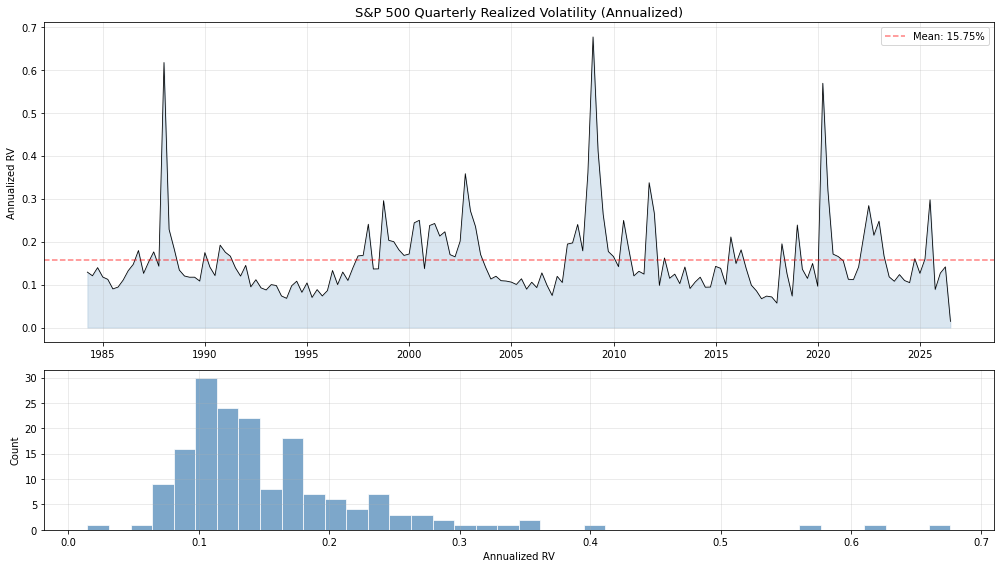

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [2, 1]})
axes[0].plot(quarterly_rv.index.to_numpy(), quarterly_rv.values, 'k-', lw=0.8)
axes[0].fill_between(quarterly_rv.index.to_numpy(), 0, quarterly_rv.values, alpha=0.2, color='steelblue')
axes[0].set_title('S&P 500 Quarterly Realized Volatility (Annualized)', fontsize=13)
axes[0].set_ylabel('Annualized RV')
axes[0].axhline(y=quarterly_rv.mean(), color='red', ls='--', alpha=0.5,
                label=f'Mean: {quarterly_rv.mean():.2%}')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].hist(quarterly_rv.values, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].set_xlabel('Annualized RV'); axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/rv_target.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Align, clean, and check

In [15]:
# Find common date range
m_start = monthly_transformed.dropna(how='all').index.min()
m_end = monthly_transformed.dropna(how='all').index.max()
q_start = quarterly_transformed.dropna(how='all').index.min()
q_end = quarterly_transformed.dropna(how='all').index.max()
rv_start = quarterly_rv.index.min()
rv_end = quarterly_rv.index.max()

common_start = max(m_start, q_start, rv_start)
common_end = min(m_end, q_end, rv_end)

print(f'Monthly:   {m_start} to {m_end}')
print(f'Quarterly: {q_start} to {q_end}')
print(f'RV:        {rv_start} to {rv_end}')
print(f'Common:    {common_start} to {common_end}')

# Trim each panel to common range
monthly_trimmed = monthly_transformed[common_start:common_end].copy()
quarterly_trimmed = quarterly_transformed[common_start:common_end].copy()
rv_trimmed = quarterly_rv[common_start:common_end].copy()

print(f'\nTrimmed shapes:')
print(f'  Monthly:   {monthly_trimmed.shape}')
print(f'  Quarterly: {quarterly_trimmed.shape}')
print(f'  RV target: {len(rv_trimmed)} quarters')
nan_pct = monthly_trimmed.isna().mean() * 100
print(f'\nMonthly NaN % (all should be low):')
print(nan_pct[nan_pct > 0].round(1).to_string() if (nan_pct > 0).any() else '  All zero — perfect!')


Monthly:   1959-01-01 00:00:00 to 2026-04-01 00:00:00
Quarterly: 1959-04-01 00:00:00 to 2026-01-01 00:00:00
RV:        1984-03-31 00:00:00 to 2026-06-30 00:00:00
Common:    1984-03-31 00:00:00 to 2026-01-01 00:00:00

Trimmed shapes:
  Monthly:   (502, 31)
  Quarterly: (168, 5)
  RV target: 168 quarters

Monthly NaN % (all should be low):
HWI         40.0
CLF16OV      0.4
CE16OV       0.4
UEMPMEAN     0.4
BUSINVx     18.7
RETAILx     18.7
M2REAL       0.4
S&P 500     76.7


In [16]:
# Quick sanity check
print(f'Monthly date range: {monthly_trimmed.index.min()} to {monthly_trimmed.index.max()}')
print(f'First 3 dates: {monthly_trimmed.index[:3].tolist()}')
print(f'Shape: {monthly_trimmed.shape}, Total NaNs: {monthly_trimmed.isna().sum().sum()}')
print(f'\nSample (first 3 rows, first 5 cols):')
print(monthly_trimmed.iloc[:3, :5])


Monthly date range: 1984-04-01 00:00:00 to 2026-01-01 00:00:00
First 3 dates: [Timestamp('1984-04-01 00:00:00'), Timestamp('1984-05-01 00:00:00'), Timestamp('1984-06-01 00:00:00')]
Shape: (502, 31), Total NaNs: 782

Sample (first 3 rows, first 5 cols):
                 RPI    INDPRO  HWI   CLF16OV    CE16OV
1984-04-01  0.006297  0.005899  NaN  0.003410  0.003543
1984-05-01  0.002150  0.005413  NaN  0.004860  0.008180
1984-06-01  0.007413  0.003661  NaN  0.001477  0.003776


In [17]:
def clean_panel(df, name, max_nan_pct=15, max_ffill=3):
    nan_pct = df.isna().mean() * 100
    print(f'\n=== {name} ===')
    drop = nan_pct[nan_pct > max_nan_pct].index.tolist()
    if drop:
        print(f'Dropping (>{max_nan_pct}% NaN): {drop}')
        df = df.drop(columns=drop)
    df = df.ffill(limit=max_ffill).bfill(limit=max_ffill)
    remaining = df.isna().sum().sum()
    if remaining > 0:
        print(f'Filling {remaining} remaining NaNs with column median')
        df = df.fillna(df.median())
    print(f'Final: {df.shape}, NaNs: {df.isna().sum().sum()}')
    return df

monthly_clean = clean_panel(monthly_trimmed, 'Monthly')
quarterly_clean = clean_panel(quarterly_trimmed, 'Quarterly')


=== Monthly ===
Dropping (>15% NaN): ['HWI', 'BUSINVx', 'RETAILx', 'S&P 500']
Final: (502, 27), NaNs: 0

=== Quarterly ===
Final: (168, 5), NaNs: 0


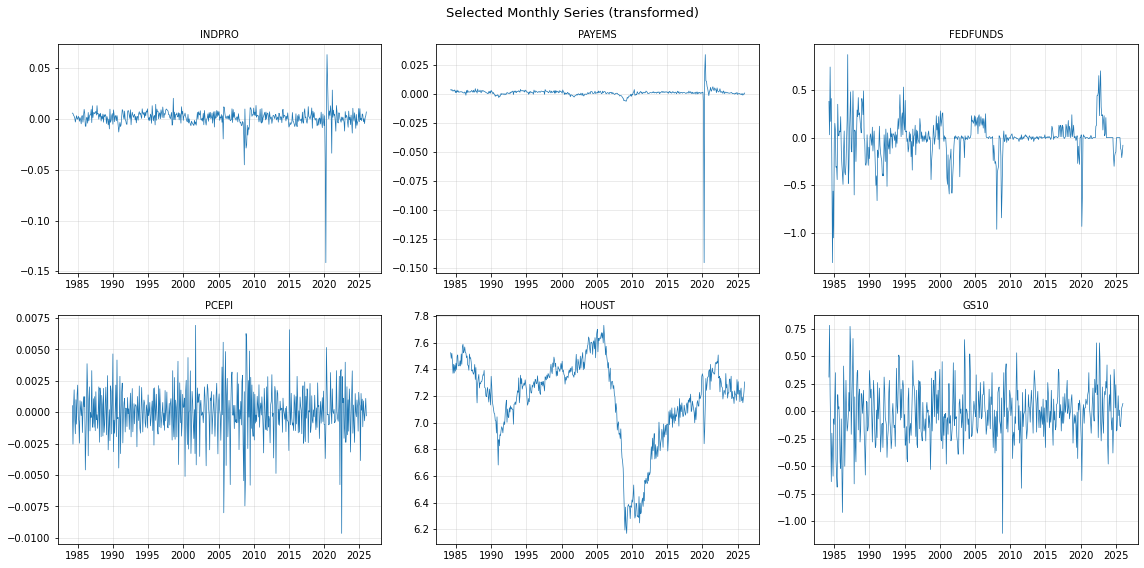

In [18]:
# Plot key series to sanity-check transformations
key_vars = [v for v in ['INDPRO', 'PAYEMS', 'FEDFUNDS', 'PCEPI', 'HOUST', 'GS10']
            if v in monthly_clean.columns]

if len(key_vars) > 0:
    ncols = min(3, len(key_vars))
    nrows = (len(key_vars) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes_flat = [axes] if len(key_vars) == 1 else axes.flat
    for ax, var in zip(axes_flat, key_vars):
        ax.plot(monthly_clean.index.to_numpy(), monthly_clean[var].values, lw=0.7)
        ax.set_title(var, fontsize=10); ax.grid(True, alpha=0.3)
    plt.suptitle('Selected Monthly Series (transformed)', fontsize=13)
    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}/monthly_check.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No key variables found — check monthly_clean columns.')


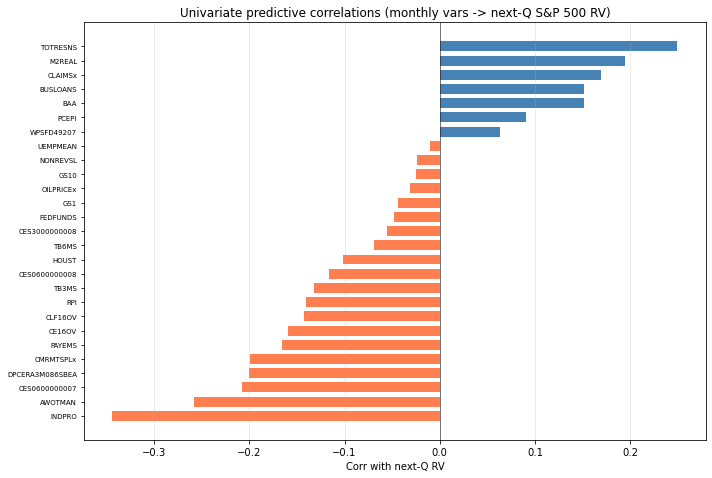

Top 5 positive:
BAA         0.150772
BUSLOANS    0.151300
CLAIMSx     0.169310
M2REAL      0.194643
TOTRESNS    0.249229

Top 5 negative:
INDPRO            -0.343532
AWOTMAN           -0.257585
CES0600000007     -0.207539
DPCERA3M086SBEA   -0.200031
CMRMTSPLx         -0.199088


In [21]:
# Predictive correlations: current monthly vars -> next-quarter RV
monthly_qend = monthly_clean.resample('Q').last()
common_idx = monthly_qend.index.intersection(rv_trimmed.index)

if len(common_idx) > 2:
    corr = monthly_qend.loc[common_idx].shift(1).corrwith(
        rv_trimmed.loc[common_idx]).dropna().sort_values()

    fig, ax = plt.subplots(figsize=(10, max(4, len(corr) * 0.25)))
    colors = ['steelblue' if c > 0 else 'coral' for c in corr.values]
    ax.barh(range(len(corr)), corr.values, color=colors, height=0.7)
    ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index, fontsize=7)
    ax.set_xlabel('Corr with next-Q RV')
    ax.set_title('Univariate predictive correlations (monthly vars -> next-Q S&P 500 RV)')
    ax.axvline(0, color='k', lw=0.5); ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig(f'{DATA_DIR}/corr_with_rv.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Top 5 positive:'); print(corr.tail(5).to_string())
    print('\nTop 5 negative:'); print(corr.head(5).to_string())
else:
    print('Not enough overlapping dates for correlation analysis.')


## 6. Train / Validation / Test split & save

Total: 168 quarters
Train: 121  (1984-03-31T00:00:00.000000000 to 2014-03-31T00:00:00.000000000)
Val:   13   (2014-06-30T00:00:00.000000000 to 2017-06-30T00:00:00.000000000)
Test:  34  (2017-09-30T00:00:00.000000000 to 2025-12-31T00:00:00.000000000)


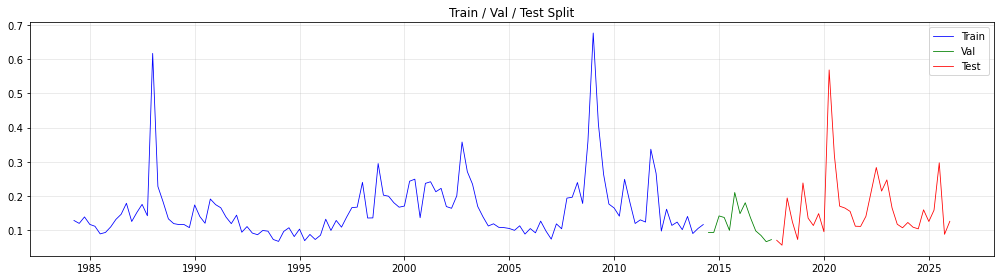

In [22]:
n_q = len(rv_trimmed)
n_train_total = int(n_q * 0.80)
n_val = int(n_train_total * 0.10)
n_train = n_train_total - n_val
n_test = n_q - n_train_total
rv_dates = rv_trimmed.index.to_numpy()
rv_vals = rv_trimmed.values

print(f'Total: {n_q} quarters')
print(f'Train: {n_train}  ({rv_dates[0]} to {rv_dates[n_train-1]})')
print(f'Val:   {n_val}   ({rv_dates[n_train]} to {rv_dates[n_train+n_val-1]})')
print(f'Test:  {n_test}  ({rv_dates[n_train+n_val]} to {rv_dates[-1]})')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(rv_dates[:n_train], rv_vals[:n_train], 'b-', lw=0.8, label='Train')
ax.plot(rv_dates[n_train:n_train+n_val], rv_vals[n_train:n_train+n_val],
        'g-', lw=0.8, label='Val')
ax.plot(rv_dates[n_train+n_val:], rv_vals[n_train+n_val:], 'r-', lw=0.8, label='Test')
ax.set_title('Train / Val / Test Split'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{DATA_DIR}/split.png', dpi=150, bbox_inches='tight')
plt.show()


In [23]:
# Save everything
monthly_clean.to_csv(f'{DATA_DIR}/monthly_panel_transformed.csv')
quarterly_clean.to_csv(f'{DATA_DIR}/quarterly_panel_transformed.csv')
rv_trimmed.to_frame().to_csv(f'{DATA_DIR}/rv_target_quarterly.csv')

metadata = {
    'monthly_vars': list(monthly_clean.columns),
    'quarterly_vars': list(quarterly_clean.columns),
    'monthly_tcodes': {k: v[1] for k, v in MONTHLY_VARS.items() if k in monthly_clean.columns},
    'quarterly_tcodes': {k: v[1] for k, v in QUARTERLY_VARS.items() if k in quarterly_clean.columns},
    'date_range': {'start': str(common_start), 'end': str(common_end)},
    'split': {'n_train': n_train, 'n_val': n_val, 'n_test': n_test,
              'train_end': str(rv_trimmed.index[n_train-1]),
              'val_end': str(rv_trimmed.index[n_train+n_val-1])},
    'target': 'S&P 500 quarterly realized volatility (annualized)',
}
with open(f'{DATA_DIR}/metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Saved:')
for fname in sorted(os.listdir(DATA_DIR)):
    print(f'  {fname:45s} {os.path.getsize(f"{DATA_DIR}/{fname}")/1024:.1f} KB')

print(f'\nMonthly panel: {monthly_clean.shape}')
print(f'Quarterly panel: {quarterly_clean.shape}')
print(f'RV target: {len(rv_trimmed)} quarters')


Saved:
  corr_with_rv.png                              50.7 KB
  metadata.json                                 1.5 KB
  monthly_check.png                             362.1 KB
  monthly_panel_transformed.csv                 267.9 KB
  quarterly_panel_transformed.csv               18.5 KB
  rv_target.png                                 145.8 KB
  rv_target_quarterly.csv                       5.2 KB
  sp500_daily.csv                               0.0 KB
  split.png                                     72.4 KB

Monthly panel: (502, 27)
Quarterly panel: (168, 5)
RV target: 168 quarters


## 7. Fama-French Factor Data

In [24]:
import pandas_datareader.data as web

# 5 Fama-French factors + RF
ff5 = web.DataReader('F-F_Research_Data_5_Factors_2x3', 'famafrench', start='1963-01-01')
ff5_monthly = ff5[0]

# Momentum
mom = web.DataReader('F-F_Momentum_Factor', 'famafrench', start='1963-01-01')
mom_monthly = mom[0]

# Combine and clean
factors_all = ff5_monthly.join(mom_monthly) / 100  # pct to decimal
factors_all.index = factors_all.index.to_timestamp()

factor_names = ['SMB', 'HML', 'RMW', 'CMA', 'Mom']
factor_returns = factors_all[factor_names]

print(f'Factor returns: {factor_returns.shape}')
print(f'Range: {factor_returns.index.min()} to {factor_returns.index.max()}')
print(f'Columns: {list(factors_all.columns)}')

# Save
factors_all.to_csv(f'{DATA_DIR}/ff_factors_monthly.csv')
print(f'Saved to {DATA_DIR}/ff_factors_monthly.csv')


Factor returns: (752, 5)
Range: 1963-07-01 00:00:00 to 2026-02-01 00:00:00
Columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF', 'Mom']
Saved to ./data/ff_factors_monthly.csv


## Checklist

- [ ] 34 monthly + 13 quarterly FRED vars downloaded
- [ ] Transformed series look stationary
- [ ] RV spikes during GFC and COVID
- [ ] Fama-French 5 factors + momentum loaded
- [ ] All data saved to `./data/`

### Outputs
- `monthly_panel_transformed.csv`
- `quarterly_panel_transformed.csv`
- `rv_target_quarterly.csv`
- `ff_factors_monthly.csv`
- `metadata.json`